# 02 — Saliency Metrics and MeanMap Baseline

This notebook defines and validates the **common mathematical evaluation framework**
used by the Efficient Multi-Scale Visual Saliency Prediction project.

The previous stages are already complete:

- `00_dataset_preparation.ipynb` audited SALICON, matched images and maps, and
  created the fixed train, validation, and internal test splits;
- `01_data_pipeline.ipynb` validated the reusable PyTorch data pipeline implemented
  in `src/data.py`;
- every target returned by `SaliconDataset` is already a non-negative tensor with
  shape `[1, H, W]` whose pixels sum to one.

This notebook does **not** implement or train a neural network.

Its objectives are to:

1. import and validate the functions implemented in `src/losses_metrics.py`;
2. verify KLD, CC, and SIM on controlled artificial maps;
3. verify the conversion from raw model logits to spatial probability maps;
4. verify that the final training loss supports backpropagation;
5. construct the non-learned training-set **MeanMap** baseline;
6. evaluate MeanMap on the validation split;
7. save the baseline tensor, figure, qualitative panel, and validation metrics.

The internal test split is deliberately not used here. It remains reserved for the
final evaluation stage.

## 1. Position in the complete project

The project studies whether compact multi-scale feature fusion improves saliency
prediction without losing the efficiency advantages of a lightweight encoder.

The controlled comparison is:

| Method | Encoder | Decoder | Purpose |
|---|---|---|---|
| **MeanMap** | None | None | Dataset-level spatial-prior baseline |
| **Light-S** | MobileNetV2 | Deepest feature only | Lightweight single-scale baseline |
| **Light-M** | MobileNetV2 | Multi-scale decoder | Main proposed model |
| **Heavy-M** | ResNet-18 | Same multi-scale decoder | Larger accuracy-oriented reference |

The full project pipeline is:

```text
Dataset audit and fixed splits
        ↓
Reusable PyTorch data pipeline
        ↓
Metrics and MeanMap baseline       ← current notebook
        ↓
Model architectures
        ↓
Shared training and evaluation loop
        ↓
Light-S, Light-M, Heavy-M training
        ↓
Final accuracy, efficiency, and centre-bias comparison
        ↓
Six-page report
```

This notebook creates the measurement system used by every later experiment.
No architectural result is meaningful until the measurement system is correct.

## 2. Why metrics are implemented before the models

Implementing the metrics first is an experimental-design decision, not merely a
coding preference.

### 2.1 One fixed definition for every model

Light-S, Light-M, and Heavy-M must use exactly the same:

- target representation;
- prediction representation;
- training loss;
- validation metrics;
- aggregation procedure.

This ensures that later differences are caused by the architectures rather than by
different mathematical conventions.

### 2.2 Mathematical bugs must be isolated early

A model may appear to train even when:

- softmax is applied over the wrong dimension;
- KLD arguments are reversed;
- the batch is normalized as one distribution;
- a constant map produces NaN correlation;
- metrics are averaged incorrectly across batches.

Controlled synthetic tests expose these problems before GPU time is spent.

### 2.3 The baseline gives context to neural-model scores

SALICON contains a strong spatial prior: observers often look near the image centre.
MeanMap predicts the average training saliency map for every image and therefore uses
no RGB content.

If a neural model cannot clearly improve over MeanMap, it may be learning mainly the
dataset prior instead of image-dependent attention.

## 3. Mathematical contract used throughout the project

### 3.1 Ground-truth target

Let $M_i$ be the resized raw saliency value at pixel $i$.
`src/data.py` clamps negative values and normalizes every sample:

$$
G_i =
\frac{\max(M_i,0)}
{\sum_{j=1}^{HW}\max(M_j,0)}.
$$

Therefore:

$$
G_i \geq 0,
\qquad
\sum_{i=1}^{HW}G_i = 1.
$$

The target is normalized **once in the data pipeline**. The metric functions verify
this contract when requested but do not silently normalize the target again.

### 3.2 Model output and spatial softmax

A neural model will return raw logits:

$$
Z = f_\theta(I),
$$

with shape `[B, 1, H, W]`.

Logits are converted into a probability distribution over all image locations:

$$
P_i =
\frac{\exp(Z_i)}
{\sum_{j=1}^{HW}\exp(Z_j)}.
$$

The softmax is applied over the complete $H \times W$ spatial grid for each image,
not over the one-channel dimension.

### 3.3 Kullback–Leibler divergence

$$
D_{\mathrm{KL}}(G\|P)
=
\sum_i
G_i
\log
\left(
\frac{G_i+\epsilon}
{P_i+\epsilon}
\right).
$$

- lower is better;
- zero means identical distributions;
- the direction is $G\|P$, because KLD is asymmetric.

### 3.4 Correlation coefficient

$$
CC(P,G)
=
\frac{
\sum_i (P_i-\mu_P)(G_i-\mu_G)
}{
\sqrt{\sum_i(P_i-\mu_P)^2}
\sqrt{\sum_i(G_i-\mu_G)^2}
+\epsilon
}.
$$

- higher is better;
- one means perfect positive spatial agreement;
- a constant map has zero spatial variance, so this implementation returns zero
  rather than NaN.

### 3.5 Similarity metric

$$
SIM(P,G)
=
\sum_i \min(P_i,G_i).
$$

For normalized maps:

$$
0 \leq SIM(P,G) \leq 1.
$$

Higher values indicate greater distribution overlap.

### 3.6 Final common training loss

All neural models will use:

$$
\mathcal{L}
=
D_{\mathrm{KL}}(G\|P)
+
0.5\left(1-CC(P,G)\right).
$$

KLD encourages correct probability allocation, while the CC term encourages the
correct spatial pattern. SIM remains an evaluation metric and is not included in the
training objective.

## 4. Storage and execution design

The project uses three environments with different responsibilities:

- **GitHub repository:** notebooks, source code, deterministic manifests, and report
  material;
- **Google Drive:** SALICON, checkpoints, metrics, figures, predictions, and backups;
- **Google Colab:** temporary CPU/GPU execution environment.

Files stored only under `/content` disappear when the Colab runtime resets.
Generated artifacts from this notebook are therefore written directly to Google
Drive, while the notebook and Python source files remain in GitHub.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 5. Clone or update the GitHub repository

The notebook always works from `/content/efficient-saliency-prediction`.

- If the repository is not present, it is cloned.
- If it is already present, a fast-forward-only pull retrieves committed updates.
- A fast-forward-only pull avoids silently merging conflicting local changes.

Before running this cell, make sure the completed `src/losses_metrics.py` has been
committed and pushed to GitHub.

In [3]:

from pathlib import Path

REPO_ROOT = Path("/content/efficient-saliency-prediction")

if not REPO_ROOT.exists():
    %cd /content
    !git clone https://github.com/RicoDalB/efficient-saliency-prediction.git
else:
    %cd /content/efficient-saliency-prediction
    !git pull --ff-only

%cd /content/efficient-saliency-prediction

/content
Cloning into 'efficient-saliency-prediction'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 55 (delta 17), reused 49 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.02 MiB | 3.58 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/efficient-saliency-prediction


## 6. Imports and canonical paths

The fixed split manifests are loaded from GitHub.
SALICON and generated results are loaded from or saved to Google Drive.

This notebook creates output directories when needed, but it does not recreate or
modify the dataset and split files.

In [4]:
import importlib
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")

# GitHub paths
SRC_ROOT = REPO_ROOT / "src"
SPLIT_ROOT = REPO_ROOT / "splits"

TRAIN_MANIFEST_PATH = SPLIT_ROOT / "train_manifest.csv"
VAL_MANIFEST_PATH = SPLIT_ROOT / "val_manifest.csv"

# Google Drive paths
DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
METRICS_ROOT = OUTPUT_ROOT / "metrics"
PREDICTION_ROOT = OUTPUT_ROOT / "predictions"

for path in [FIGURE_ROOT, METRICS_ROOT, PREDICTION_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

MEANMAP_FIGURE_PATH = FIGURE_ROOT / "meanmap.png"
MEANMAP_EXAMPLES_PATH = FIGURE_ROOT / "meanmap_validation_examples.png"
MEANMAP_METRICS_PATH = METRICS_ROOT / "meanmap_metrics.csv"
MEANMAP_TENSOR_PATH = PREDICTION_ROOT / "meanmap_tensor.pt"

print("Repository root:", REPO_ROOT)
print("SALICON root:", DATA_ROOT)
print("Training manifest:", TRAIN_MANIFEST_PATH)
print("Validation manifest:", VAL_MANIFEST_PATH)
print("Figure output:", FIGURE_ROOT)
print("Metric output:", METRICS_ROOT)

Repository root: /content/efficient-saliency-prediction
SALICON root: /content/drive/MyDrive/saliency_project/data/SALICON
Training manifest: /content/efficient-saliency-prediction/splits/train_manifest.csv
Validation manifest: /content/efficient-saliency-prediction/splits/val_manifest.csv
Figure output: /content/drive/MyDrive/saliency_project/outputs/figures
Metric output: /content/drive/MyDrive/saliency_project/outputs/metrics


## 7. Verify required inputs

A missing dataset or manifest should stop execution immediately.
Creating empty replacement files would hide a storage or setup problem and could
invalidate the experiment.

In [5]:
required_paths = {
    "GitHub repository": REPO_ROOT,
    "source package": SRC_ROOT,
    "SALICON dataset": DATA_ROOT,
    "train manifest": TRAIN_MANIFEST_PATH,
    "validation manifest": VAL_MANIFEST_PATH,
    "losses and metrics module": SRC_ROOT / "losses_metrics.py",
}

missing_paths = []

for name, path in required_paths.items():
    exists = path.exists()

    status = "OK" if exists else "MISSING"

    print(
        f"{name:27s} | "
        f"{status:7s} | "
        f"{path}"
    )

    if not exists:
        missing_paths.append(str(path))

assert not missing_paths, (
    "Required project files are missing:\n"
    + "\n".join(missing_paths)
)

GitHub repository           | OK      | /content/efficient-saliency-prediction
source package              | OK      | /content/efficient-saliency-prediction/src
SALICON dataset             | OK      | /content/drive/MyDrive/saliency_project/data/SALICON
train manifest              | OK      | /content/efficient-saliency-prediction/splits/train_manifest.csv
validation manifest         | OK      | /content/efficient-saliency-prediction/splits/val_manifest.csv
losses and metrics module   | OK      | /content/efficient-saliency-prediction/src/losses_metrics.py


## 8. Reproducibility and hardware information

This stage does not train a model, but it still uses the project seed and records the
execution environment.

The same seed will later control model initialization, DataLoader order, and other
stochastic operations.

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: cuda
GPU: Tesla T4


## 9. Import the reusable project modules

The responsibilities are deliberately separated:

```text
src/data.py
    loads image-map pairs
    resizes tensors
    applies ImageNet image normalization
    normalizes every target once

src/losses_metrics.py
    validates tensor contracts
    converts raw logits with spatial softmax
    computes KLD, CC, and SIM
    computes the final training loss

this notebook
    tests the mathematics
    builds and evaluates MeanMap
    saves reproducible artifacts
```

`importlib.reload` is used instead of IPython autoreload because autoreload caused a
Python 3.12 compatibility error in a previous Colab session.

In [7]:
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.data as data_module
import src.losses_metrics as losses_metrics_module

importlib.reload(data_module)
importlib.reload(losses_metrics_module)

from src.data import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    SaliconDataset,
    build_dataloader,
)

from src.losses_metrics import (
    correlation_coefficient,
    kld_divergence,
    saliency_loss,
    similarity_score,
    spatial_softmax,
    validate_spatial_distribution,
)

print("src.data imported successfully.")
print("src.losses_metrics imported successfully.")

src.data imported successfully.
src.losses_metrics imported successfully.


## 10. Construct the training and validation datasets

The same fixed manifests and preprocessing validated in
`01_data_pipeline.ipynb` are reused.

Important decisions:

- target size remains `(192, 256)`;
- ground-truth targets remain normalized by `src/data.py`;
- ImageNet normalization is kept for RGB images;
- the train split is used only to calculate MeanMap;
- the validation split is used to measure the baseline;
- the internal test split is not loaded in this notebook.

The current data pipeline contains no random augmentation. If augmentation is added
later, MeanMap must still be calculated from an unaugmented training dataset.

In [12]:
TARGET_SIZE = (192, 256)  # height, width

IMAGE_COLUMN = "image_relpath"
MAP_COLUMN = "map_relpath"
ID_COLUMN = "sample_id"

train_dataset = SaliconDataset(
    manifest_path=TRAIN_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=TARGET_SIZE,
    use_imagenet_normalization=True,
)

val_dataset = SaliconDataset(
    manifest_path=VAL_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=TARGET_SIZE,
    use_imagenet_normalization=True,
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 10000
Validation samples: 2500


## 11. Construct deterministic DataLoaders

MeanMap is an average over all training targets, so training samples are loaded in a
fixed order with `shuffle=False`.

The batch size affects only memory and execution speed. It does not affect the
result because each normalized target contributes exactly once.

In [13]:
BATCH_SIZE = 32
NUM_WORKERS = 1

meanmap_train_loader = build_dataloader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

val_loader = build_dataloader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

print("MeanMap training loader created.")
print("Validation loader created.")

MeanMap training loader created.
Validation loader created.


## 12. Validate the real target contract

Before testing artificial maps, one real SALICON batch is checked.

For every target we require:

- shape `[B, 1, 192, 256]`;
- floating-point values;
- finite values;
- non-negative values;
- total spatial mass equal to one.

This confirms that the metrics can trust the contract established by `src/data.py`.

In [22]:
real_batch = next(iter(val_loader))

real_images = real_batch["image"]
real_targets = real_batch["target"]
real_sample_ids = real_batch["sample_id"]

print("Image batch shape:", tuple(real_images.shape))
print("Target batch shape:", tuple(real_targets.shape))
print("Image dtype:", real_images.dtype)
print("Target dtype:", real_targets.dtype)
print("First sample IDs:", list(real_sample_ids[:3]))

validate_spatial_distribution(real_targets, name="real validation targets")

target_masses = real_targets.sum(dim=(1, 2, 3))
print("First target masses:", target_masses[:5])

assert real_images.shape[1:] == (3, *TARGET_SIZE)
assert real_targets.shape[1:] == (1, *TARGET_SIZE)

print("Real target contract validated.")

Image batch shape: (32, 3, 192, 256)
Target batch shape: (32, 1, 192, 256)
Image dtype: torch.float32
Target dtype: torch.float32
First sample IDs: ['1000', '100000', '100081']
First target masses: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Real target contract validated.


## 13. Controlled metric sanity tests

Synthetic maps provide known expected behaviour.

We compare one non-constant target with:

1. an identical map;
2. a horizontally shifted version;
3. a uniform distribution.

Expected behaviour:

| Comparison | KLD | CC | SIM |
|---|---:|---:|---:|
| Identical | approximately 0 | approximately 1 | approximately 1 |
| Shifted | higher | lower | lower |
| Uniform | finite | 0 for a constant map | below 1 |

The uniform-map CC is zero because a constant map has zero spatial variance.

In [23]:
base_map = torch.tensor(
    [
        [0.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 2.0, 0.0],
        [0.0, 2.0, 4.0, 0.0],
        [0.0, 0.0, 0.0, 0.0],
    ],
    dtype=torch.float32,
).reshape(1, 1, 4, 4)

base_map = base_map / base_map.sum()
identical_map = base_map.clone()
shifted_map = torch.roll(base_map, shifts=1, dims=-1)
uniform_map = torch.full_like(base_map, fill_value=1.0 / base_map.numel())

for name, maps in {
    "base_map": base_map,
    "identical_map": identical_map,
    "shifted_map": shifted_map,
    "uniform_map": uniform_map,
}.items():
    validate_spatial_distribution(maps, name=name)

print("All artificial maps are valid spatial distributions.")

All artificial maps are valid spatial distributions.


In [24]:
sanity_rows = []

for comparison_name, prediction in [
    ("identical", identical_map),
    ("shifted", shifted_map),
    ("uniform", uniform_map),
]:
    sanity_rows.append(
        {
            "comparison": comparison_name,
            "kld": kld_divergence(prediction, base_map).item(),
            "cc": correlation_coefficient(prediction, base_map).item(),
            "sim": similarity_score(prediction, base_map).item(),
        }
    )

sanity_results = pd.DataFrame(sanity_rows)
display(sanity_results)

indexed_results = sanity_results.set_index("comparison")
identical = indexed_results.loc["identical"]
shifted = indexed_results.loc["shifted"]

assert abs(identical["kld"]) < 1e-6
assert identical["cc"] > 0.999
assert identical["sim"] > 0.999

assert shifted["kld"] > identical["kld"]
assert shifted["cc"] < identical["cc"]
assert shifted["sim"] < identical["sim"]

assert np.isfinite(sanity_results[["kld", "cc", "sim"]].to_numpy()).all()

print("Metric sanity tests passed.")

,comparison,kld,cc,sim
0,identical,0.00000,1.000000,1.000000
1,shifted,6.02395,0.247649,0.333333
2,uniform,1.49956,0.000000,0.250000


Metric sanity tests passed.


## 14. Validate spatial softmax and the training loss

The future neural models will return raw logits rather than probability maps.

This test verifies the complete differentiable chain:

```text
raw logits
    ↓
spatial softmax over H × W
    ↓
probability maps whose mass is one
    ↓
KLD + 0.5 × (1 − CC)
    ↓
backpropagation
    ↓
finite, non-zero gradients
```

This is tested now so that later architecture debugging can focus on the model rather
than on the loss implementation.

In [25]:
test_logits = torch.randn(
    2,
    1,
    4,
    4,
    requires_grad=True,
)

test_targets = base_map.repeat(2, 1, 1, 1)
test_predictions = spatial_softmax(test_logits)

validate_spatial_distribution(
    test_predictions.detach(),
    name="softmax predictions",
)

prediction_masses = test_predictions.sum(dim=(1, 2, 3))
print("Prediction masses:", prediction_masses)

test_loss = saliency_loss(test_logits, test_targets)
test_loss.backward()

mean_gradient = test_logits.grad.abs().mean()

print("Test loss:", test_loss.item())
print("Mean absolute logit gradient:", mean_gradient.item())

assert torch.isfinite(test_loss)
assert torch.isfinite(test_logits.grad).all()
assert mean_gradient.item() > 0.0

print("Spatial softmax and backpropagation test passed.")

Prediction masses: tensor([1.0000, 1.0000], grad_fn=<SumBackward1>)
Test loss: 2.2302446365356445
Mean absolute logit gradient: 0.05930870771408081
Spatial softmax and backpropagation test passed.


## 15. Construct the training-set MeanMap

For normalized training targets $G_n$, the MeanMap is:

$$
M(x,y)
=
\frac{1}{N}
\sum_{n=1}^{N}
G_n(x,y).
$$

Because every training target sums to one:

$$
\sum_{x,y}M(x,y)
=
\frac{1}{N}
\sum_{n=1}^{N}
\sum_{x,y}G_n(x,y)
=
1.
$$

MeanMap is therefore already a valid spatial distribution. We validate its mass
instead of silently renormalizing all targets again.

The accumulation uses float64 to reduce numerical error across 10,000 maps. The
final stored tensor is converted back to float32.

In [33]:
from PIL import Image
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from src.data import normalized_saliency_map


@torch.inference_mode()
def compute_mean_map_from_manifest(
    manifest_path: Path,
    data_root: Path,
    map_column: str,
    output_size: tuple[int, int],
) -> torch.Tensor:
    """
    Compute MeanMap using only the saliency-map files.

    RGB images are not loaded because they are not needed.
    """
    manifest = pd.read_csv(manifest_path)

    if manifest.empty:
        raise ValueError(
            f"The manifest is empty: {manifest_path}"
        )

    if map_column not in manifest.columns:
        raise ValueError(
            f"Column {map_column!r} is missing. "
            f"Available columns: {list(manifest.columns)}"
        )

    height, width = output_size

    accumulated_map = torch.zeros(
        (1, height, width),
        dtype=torch.float64,
    )

    for map_value in tqdm(
        manifest[map_column],
        desc="Computing training MeanMap",
    ):
        map_path = Path(str(map_value))

        if not map_path.is_absolute():
            map_path = data_root / map_path

        if not map_path.is_file():
            raise FileNotFoundError(
                f"Saliency map not found: {map_path}"
            )

        with Image.open(map_path) as map_file:
            resized_map = TF.resize(
                map_file.convert("F"),
                size=[height, width],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True,
            )

            target_array = np.asarray(
                resized_map,
                dtype=np.float32,
            ).copy()

        target = torch.from_numpy(
            target_array
        ).unsqueeze(0)

        target = normalized_saliency_map(
            target
        )

        accumulated_map += target.to(
            dtype=torch.float64
        )

    mean_map = (
        accumulated_map / len(manifest)
    ).to(dtype=torch.float32)

    validate_spatial_distribution(
        mean_map.unsqueeze(0),
        name="training MeanMap",
        atol=1e-4,
    )

    return mean_map

In [34]:
mean_map = compute_mean_map_from_manifest(
    manifest_path=TRAIN_MANIFEST_PATH,
    data_root=DATA_ROOT,
    map_column=MAP_COLUMN,
    output_size=TARGET_SIZE,
)
print("MeanMap shape:", tuple(mean_map.shape))
print("MeanMap dtype:", mean_map.dtype)
print("MeanMap minimum:", mean_map.min().item())
print("MeanMap maximum:", mean_map.max().item())
print("MeanMap total mass:", mean_map.sum().item())

torch.save(mean_map, MEANMAP_TENSOR_PATH)

print("Saved MeanMap tensor:", MEANMAP_TENSOR_PATH)

Computing training MeanMap:   0%|          | 0/10000 [00:00<?, ?it/s]

MeanMap shape: (1, 192, 256)
MeanMap dtype: torch.float32
MeanMap minimum: 3.3225393547553494e-09
MeanMap maximum: 8.475226786686108e-05
MeanMap total mass: 1.0
Saved MeanMap tensor: /content/drive/MyDrive/saliency_project/outputs/predictions/meanmap_tensor.pt


In [8]:
assert MEANMAP_TENSOR_PATH.is_file(), (
    f"Saved MeanMap not found: {MEANMAP_TENSOR_PATH}"
)

mean_map = torch.load(
    MEANMAP_TENSOR_PATH,
    map_location="cpu",
)

validate_spatial_distribution(
    mean_map.unsqueeze(0),
    name="loaded MeanMap",
    atol=1e-4,
)

print("MeanMap loaded from Google Drive.")
print("Shape:", tuple(mean_map.shape))
print("Dtype:", mean_map.dtype)
print("Minimum:", mean_map.min().item())
print("Maximum:", mean_map.max().item())
print("Total mass:", mean_map.sum().item())

MeanMap loaded from Google Drive.
Shape: (1, 192, 256)
Dtype: torch.float32
Minimum: 3.3225393547553494e-09
Maximum: 8.475226786686108e-05
Total mass: 1.0


## 16. Visualize and save MeanMap

The figure displays the average spatial attention prior in the SALICON training
split.

A stronger response near the centre is expected. This is not a learned image
prediction; it is the same fixed distribution that will be used for every validation
sample.

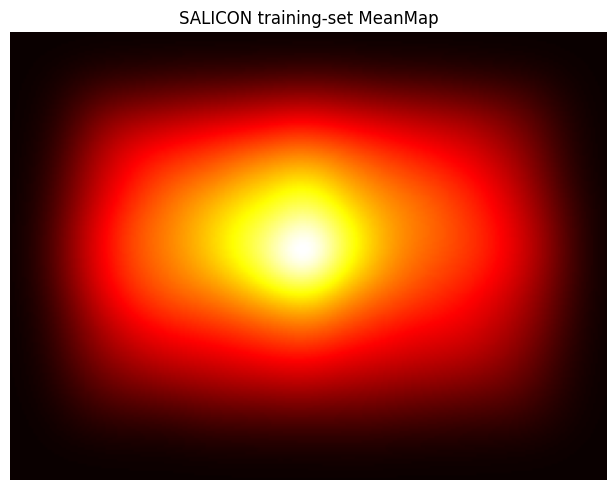

Saved MeanMap figure: /content/drive/MyDrive/saliency_project/outputs/figures/meanmap.png


In [9]:
plt.figure(figsize=(8, 5))
plt.imshow(mean_map.squeeze(0).cpu().numpy(), cmap="hot")
plt.title("SALICON training-set MeanMap")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    MEANMAP_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved MeanMap figure:", MEANMAP_FIGURE_PATH)

## 17. Evaluate MeanMap on the validation split

For every validation image, the prediction is the same MeanMap.

Metrics are calculated per image and then summed across the entire validation split.
The final average is divided by the total number of images.

This is preferable to averaging batch means because the last batch may be smaller
than the others.

In [16]:
from pathlib import Path

DRIVE_VAL_MAP_ROOT = DATA_ROOT / "maps" / "val"

LOCAL_DATA_ROOT = Path("/content/SALICON")
LOCAL_VAL_MAP_ROOT = LOCAL_DATA_ROOT / "maps" / "val"

LOCAL_VAL_MAP_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Drive validation maps:", DRIVE_VAL_MAP_ROOT)
print("Local validation maps:", LOCAL_VAL_MAP_ROOT)

Drive validation maps: /content/drive/MyDrive/saliency_project/data/SALICON/maps/val
Local validation maps: /content/SALICON/maps/val


In [17]:
!rsync -a \
    "{DRIVE_VAL_MAP_ROOT}/" \
    "{LOCAL_VAL_MAP_ROOT}/"

In [18]:
local_val_map_count = sum(
    1
    for path in LOCAL_VAL_MAP_ROOT.iterdir()
    if path.is_file()
)

print("Validation maps copied locally:", local_val_map_count)

assert local_val_map_count > 0

Validation maps copied locally: 5000


In [19]:
from PIL import Image
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

from src.data import normalized_saliency_map


def load_saliency_target(
    map_path: Path,
    output_size: tuple[int, int],
) -> torch.Tensor:
    """
    Load and preprocess one saliency map.

    The returned tensor has:
        shape [1, H, W]
        non-negative values
        total spatial mass equal to 1
    """
    if not map_path.is_file():
        raise FileNotFoundError(
            f"Saliency map not found: {map_path}"
        )

    height, width = output_size

    with Image.open(map_path) as map_file:
        resized_map = TF.resize(
            map_file.convert("F"),
            size=[height, width],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        target_array = np.asarray(
            resized_map,
            dtype=np.float32,
        ).copy()

    target = torch.from_numpy(
        target_array
    ).unsqueeze(0)

    return normalized_saliency_map(target)


@torch.inference_mode()
def evaluate_mean_map_from_manifest(
    manifest_path: Path,
    data_root: Path,
    map_column: str,
    output_size: tuple[int, int],
    mean_map: torch.Tensor,
    batch_size: int = 64,
) -> dict[str, float | int]:
    """
    Evaluate MeanMap using only validation saliency maps.

    RGB images are not loaded because they are unnecessary
    for evaluating a fixed MeanMap prediction.
    """
    manifest = pd.read_csv(manifest_path)

    if manifest.empty:
        raise ValueError(
            f"The validation manifest is empty: {manifest_path}"
        )

    if map_column not in manifest.columns:
        raise ValueError(
            f"Column {map_column!r} is missing. "
            f"Available columns: {list(manifest.columns)}"
        )

    validate_spatial_distribution(
        mean_map.unsqueeze(0),
        name="MeanMap",
        atol=1e-4,
    )

    metric_totals = {
        "kld": 0.0,
        "cc": 0.0,
        "sim": 0.0,
    }

    sample_count = 0
    pending_targets = []

    def evaluate_target_batch(
        target_list: list[torch.Tensor],
    ) -> None:
        nonlocal sample_count

        targets = torch.stack(
            target_list,
            dim=0,
        )

        current_batch_size = targets.shape[0]

        predictions = (
            mean_map
            .unsqueeze(0)
            .expand(
                current_batch_size,
                -1,
                -1,
                -1,
            )
        )

        batch_kld = kld_divergence(
            predictions,
            targets,
            reduction="none",
        )

        batch_cc = correlation_coefficient(
            predictions,
            targets,
            reduction="none",
        )

        batch_sim = similarity_score(
            predictions,
            targets,
            reduction="none",
        )

        metric_totals["kld"] += batch_kld.sum().item()
        metric_totals["cc"] += batch_cc.sum().item()
        metric_totals["sim"] += batch_sim.sum().item()

        sample_count += current_batch_size

    for map_value in tqdm(
        manifest[map_column],
        desc="Evaluating MeanMap",
    ):
        map_path = Path(str(map_value))

        if not map_path.is_absolute():
            map_path = data_root / map_path

        target = load_saliency_target(
            map_path=map_path,
            output_size=output_size,
        )

        pending_targets.append(target)

        if len(pending_targets) == batch_size:
            evaluate_target_batch(
                pending_targets
            )

            pending_targets = []

    # Process the final partial batch.
    if pending_targets:
        evaluate_target_batch(
            pending_targets
        )

    if sample_count == 0:
        raise RuntimeError(
            "No validation saliency maps were evaluated."
        )

    return {
        "num_samples": sample_count,
        "kld": metric_totals["kld"] / sample_count,
        "cc": metric_totals["cc"] / sample_count,
        "sim": metric_totals["sim"] / sample_count,
    }


In [20]:
meanmap_validation = evaluate_mean_map_from_manifest(
    manifest_path=VAL_MANIFEST_PATH,
    data_root=LOCAL_DATA_ROOT,
    map_column=MAP_COLUMN,
    output_size=TARGET_SIZE,
    mean_map=mean_map,
    batch_size=64,
)

meanmap_metrics_df = pd.DataFrame(
    [
        {
            "model": "meanmap",
            "split": "validation",
            "num_samples": meanmap_validation["num_samples"],
            "height": TARGET_SIZE[0],
            "width": TARGET_SIZE[1],
            "kld": meanmap_validation["kld"],
            "cc": meanmap_validation["cc"],
            "sim": meanmap_validation["sim"],
        }
    ]
)

meanmap_metrics_df.to_csv(
    MEANMAP_METRICS_PATH,
    index=False,
)

display(meanmap_metrics_df)

print(
    "Saved validation metrics:",
    MEANMAP_METRICS_PATH,

)

Evaluating MeanMap:   0%|          | 0/2500 [00:00<?, ?it/s]

,model,split,num_samples,height,width,kld,cc,sim
0,meanmap,validation,2500,192,256,0.712073,0.558274,0.556239


Saved validation metrics: /content/drive/MyDrive/saliency_project/outputs/metrics/meanmap_metrics.csv


## 18. Qualitative validation inspection

A deterministic set of validation indices is displayed.

Each row contains:

1. the RGB image;
2. its ground-truth saliency distribution;
3. the same MeanMap prediction.

The selected indices are spread across the validation dataset and are not chosen
according to model performance. This panel is a pipeline sanity check, not the final
report comparison.

The RGB tensors are inverse-normalized only for visualization. This does not change
the data used by the model pipeline.

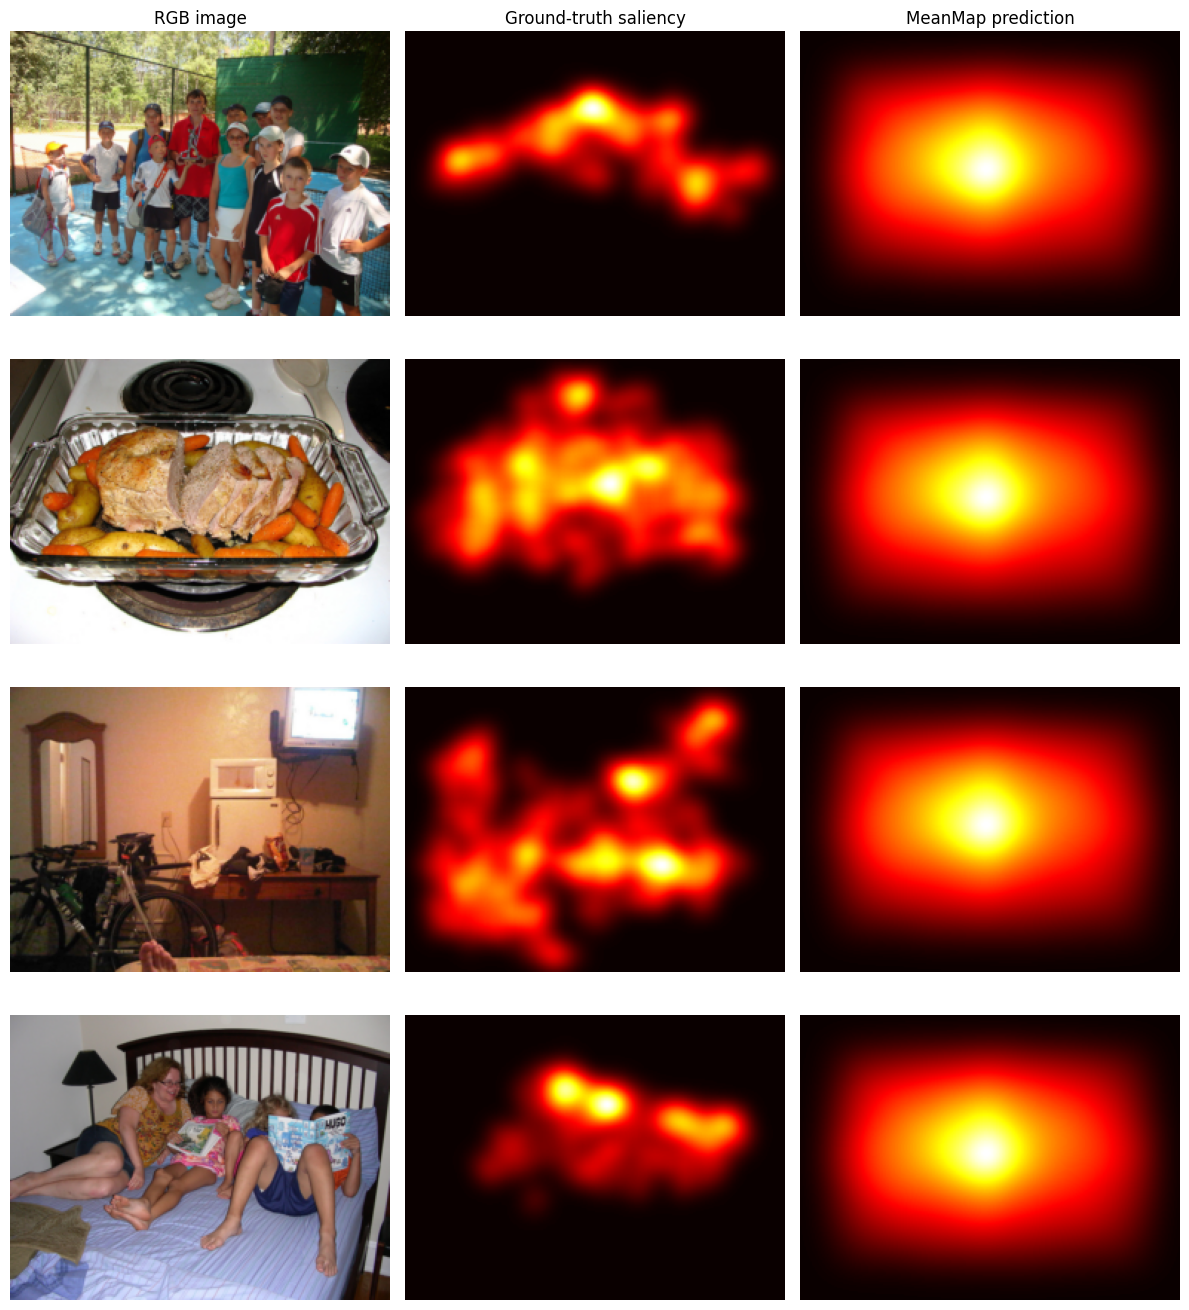

Saved qualitative panel: /content/drive/MyDrive/saliency_project/outputs/figures/meanmap_validation_examples.png


In [21]:
def image_tensor_to_display(image: torch.Tensor) -> np.ndarray:
    # Undo ImageNet normalization only for display.
    mean = torch.tensor(IMAGENET_MEAN, dtype=image.dtype).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, dtype=image.dtype).view(3, 1, 1)

    restored = image.cpu() * std + mean
    restored = restored.clamp(0.0, 1.0)

    return restored.permute(1, 2, 0).numpy()


example_indices = [
    0,
    len(val_dataset) // 3,
    2 * len(val_dataset) // 3,
    len(val_dataset) - 1,
]

fig, axes = plt.subplots(
    nrows=len(example_indices),
    ncols=3,
    figsize=(12, 3.4 * len(example_indices)),
)

column_titles = [
    "RGB image",
    "Ground-truth saliency",
    "MeanMap prediction",
]

for column_index, title in enumerate(column_titles):
    axes[0, column_index].set_title(title, fontsize=12)

for row_index, dataset_index in enumerate(example_indices):
    sample = val_dataset[dataset_index]

    image = sample["image"]
    target = sample["target"]
    sample_id = sample["sample_id"]

    axes[row_index, 0].imshow(image_tensor_to_display(image))
    axes[row_index, 1].imshow(target.squeeze(0).numpy(), cmap="hot")
    axes[row_index, 2].imshow(mean_map.squeeze(0).numpy(), cmap="hot")

    axes[row_index, 0].set_ylabel(f"ID {sample_id}", fontsize=10)

    for column_index in range(3):
        axes[row_index, column_index].axis("off")

plt.tight_layout()

plt.savefig(
    MEANMAP_EXAMPLES_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved qualitative panel:", MEANMAP_EXAMPLES_PATH)

## 19. How to interpret the MeanMap result

After executing the notebook, record the three validation scores:

- **KLD:** lower is better;
- **CC:** higher is better;
- **SIM:** higher is better.

The scores do not need to be extremely high to be useful. MeanMap serves as a
minimum scientific reference:

- it quantifies how much can be achieved from the average dataset prior;
- it gives the neural models a baseline they must improve upon;
- it provides a first warning against centre-collapse;
- it will later be evaluated on the off-centre subset using the same metric code.

Do not compare these values directly with external papers unless the dataset split,
target preprocessing, output resolution, and metric definitions are identical.

## 20. Verify saved artifacts

This final code cell confirms that the persistent outputs exist in Google Drive.

The notebook itself and `src/losses_metrics.py` belong in GitHub. The generated
tensor, figures, and CSV remain in Drive.

In [22]:
saved_artifacts = {
    "MeanMap tensor": MEANMAP_TENSOR_PATH,
    "MeanMap figure": MEANMAP_FIGURE_PATH,
    "qualitative panel": MEANMAP_EXAMPLES_PATH,
    "validation metrics": MEANMAP_METRICS_PATH,
}

for name, path in saved_artifacts.items():
    assert path.is_file(), f"Missing artifact: {path}"
    print(f"{name:22s} | OK | {path}")

loaded_metrics = pd.read_csv(MEANMAP_METRICS_PATH)
assert len(loaded_metrics) == 1
assert loaded_metrics.loc[0, "model"] == "meanmap"
assert loaded_metrics.loc[0, "split"] == "validation"

loaded_mean_map = torch.load(MEANMAP_TENSOR_PATH, map_location="cpu")

validate_spatial_distribution(
    loaded_mean_map.unsqueeze(0),
    name="reloaded MeanMap",
    atol=1e-4,
)

print("All saved artifacts were reloaded successfully.")

MeanMap tensor         | OK | /content/drive/MyDrive/saliency_project/outputs/predictions/meanmap_tensor.pt
MeanMap figure         | OK | /content/drive/MyDrive/saliency_project/outputs/figures/meanmap.png
qualitative panel      | OK | /content/drive/MyDrive/saliency_project/outputs/figures/meanmap_validation_examples.png
validation metrics     | OK | /content/drive/MyDrive/saliency_project/outputs/metrics/meanmap_metrics.csv
All saved artifacts were reloaded successfully.


## 22. GitHub checkpoint

After the notebook runs successfully from beginning to end:

```bash
cd /content/efficient-saliency-prediction

git status

git add \
  src/losses_metrics.py \
  notebooks/02_metrics_meanmap.ipynb

git commit -m "Add saliency metrics and MeanMap baseline"

git push
```

Do not add SALICON, generated figures, generated CSV files, or the MeanMap tensor to
GitHub unless the repository policy is intentionally changed. These artifacts are
already stored persistently in Google Drive.